In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
df=pd.read_csv('zomato.csv',encoding='latin-1')

print("Shape",df.shape)
print("\nFirst 5 rows:")
df.head()

Shape (9551, 21)

First 5 rows:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
print("== Dataset Info ==")
print(df.info())

print("== Basic Statistics ==")
print(df.describe())

== Dataset Info ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Sw

In [7]:
print("== Null Values ==")
print(df.isnull().sum())

print("\n== Duplicate Rows ==")
print("Duplicates:",df.duplicated().sum())

== Null Values ==
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

== Duplicate Rows ==
Duplicates: 0


In [13]:
from re import T
df.dropna(subset=
          ['Cuisines'],inplace=True)
df.drop(columns=['Restaurant ID','Country Code','Locality Verbose','Switch to order menu',
                 'Is delivering now','Rating color'],inplace=True)

print("Shape after Cleaning:",df.shape)
print("\nNull values remaining:")
print(df.isnull().sum())
print("\n Data cleaned")

Shape after Cleaning: (9542, 15)

Null values remaining:
Restaurant Name         0
City                    0
Address                 0
Locality                0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Price range             0
Aggregate rating        0
Rating text             0
Votes                   0
dtype: int64

 Data cleaned


In [14]:
city_counts=df['City'].value_counts().head(10)

print("=== Q1: Top 10 Cities by Restaurant Count ===")
print(city_counts)

=== Q1: Top 10 Cities by Restaurant Count ===
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


In [16]:
cuisines=df['Cuisines'].str.split(',').explode()
cuisines=cuisines.str.strip()
top_cuisines=cuisines.value_counts().head(10)

print("=== Q2: Top 10 Most Popular Cuisines ===")
print(top_cuisines)

=== Q2: Top 10 Most Popular Cuisines ===
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


In [19]:
rating_dist=df['Rating text'].value_counts()

print("=== Q3: Restaurant Rating Distribution ===")
print(rating_dist)

print("\n=== Average Rating ===")
print("Avg Rating:",round(df['Aggregate rating'].mean(),2))

=== Q3: Restaurant Rating Distribution ===
Rating text
Average      3734
Not rated    2148
Good         2096
Very Good    1078
Excellent     300
Poor          186
Name: count, dtype: int64

=== Average Rating ===
Avg Rating: 2.67


In [22]:
delivery_rating=df.groupby('Has Online delivery')['Aggregate rating'].mean()

print("=== Q4: Online Delivery vs Average Rating ===")
print(round(delivery_rating,2))

print("\n=== Online Delivery Count ===")
print(df['Has Online delivery'].value_counts())

=== Q4: Online Delivery vs Average Rating ===
Has Online delivery
No     2.46
Yes    3.25
Name: Aggregate rating, dtype: float64

=== Online Delivery Count ===
Has Online delivery
No     7091
Yes    2451
Name: count, dtype: int64


In [25]:
price_rating=df.groupby('Price range')['Aggregate rating'].mean()

print("=== Q5:Price Range vs Aggregate Rating ===")
print(round(price_rating,2))

print("\n=== Price Range Description ===")
print("1 = Cheap | 2 = Moderate | 3 = Expensive | 4 = Very Expensive")

print("\n=== Restaurant Count by Price Range ===")
print(df['Price range'].value_counts().sort_index())

=== Q5:Price Range vs Aggregate Rating ===
Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64

=== Price Range Description ===
1 = Cheap | 2 = Moderate | 3 = Expensive | 4 = Very Expensive

=== Restaurant Count by Price Range ===
Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64


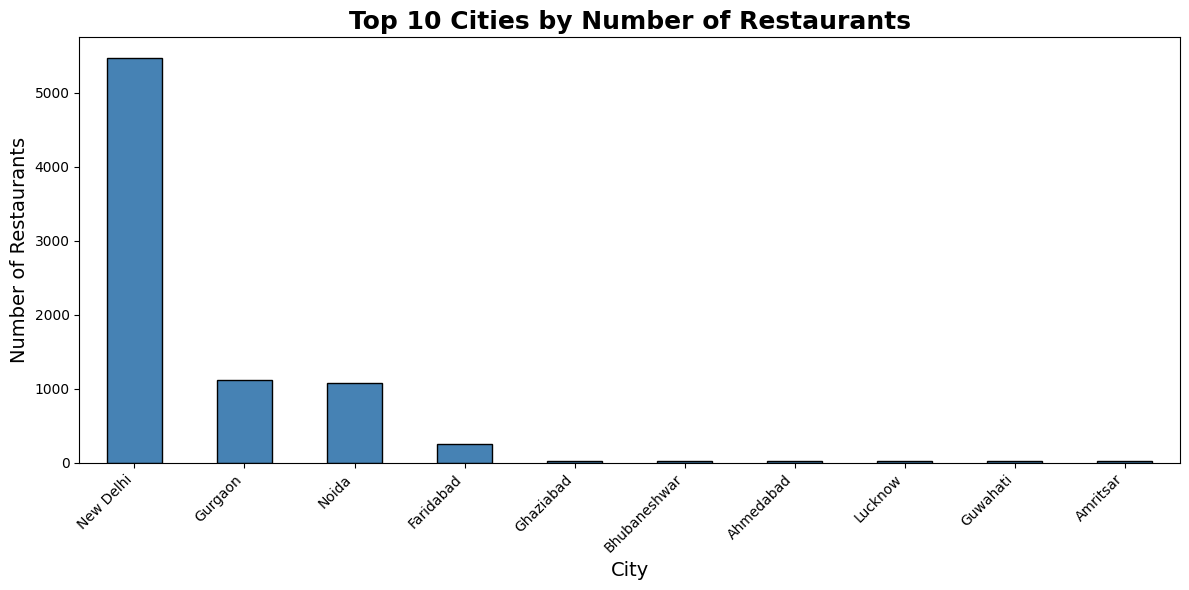

In [32]:
plt.figure(figsize=(12,6))
city_counts.plot(kind='bar',color='steelblue',edgecolor='black')
plt.title('Top 10 Cities by Number of Restaurants',fontsize=18,fontweight='bold')
plt.xlabel('City',fontsize=14)
plt.ylabel('Number of Restaurants',fontsize=14)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig('chart1_top_cities.png',dpi=150)
plt.show()

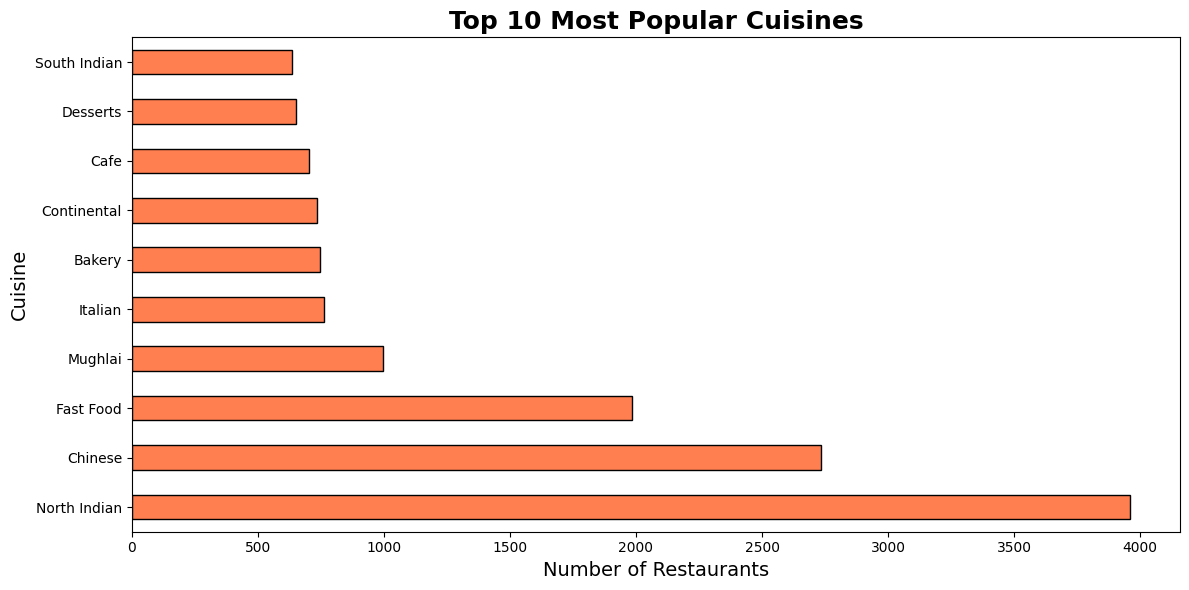

In [41]:
plt.figure(figsize=(12,6))
top_cuisines.plot(kind='barh',color='coral',edgecolor='black')
plt.title('Top 10 Most Popular Cuisines',fontsize=18,fontweight='bold')
plt.xlabel('Number of Restaurants',fontsize=14)
plt.ylabel('Cuisine',fontsize=14)
plt.tight_layout()
plt.savefig('chart2_top_cuisines.png',dpi=150)
plt.show()

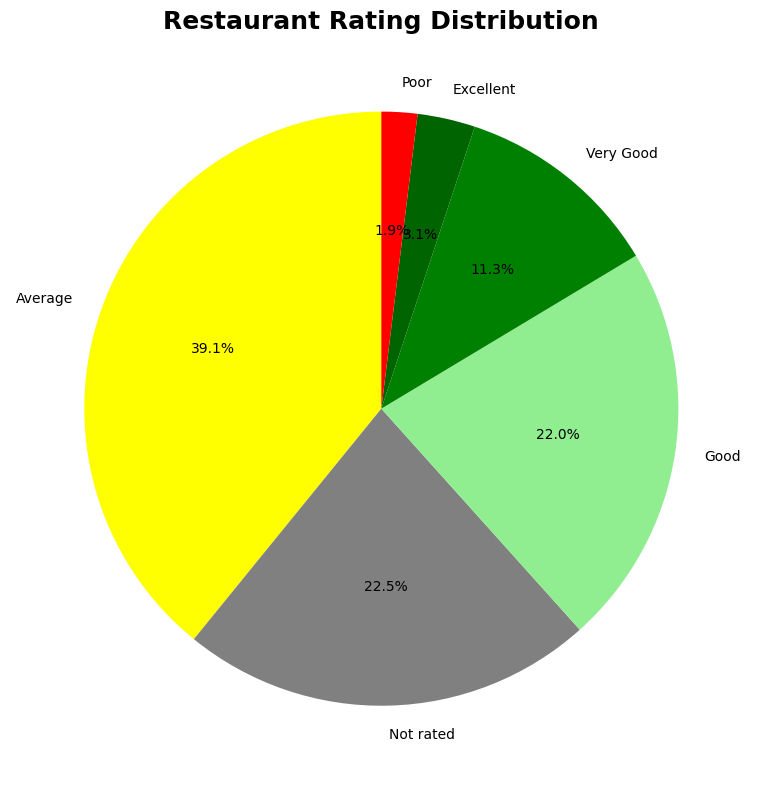

In [49]:
plt.figure(figsize=(8,8))
rating_dist.plot(kind='pie',autopct='%1.1f%%',
                 colors=['yellow','gray','lightgreen','green','darkgreen','red'],startangle=90)
plt.title('Restaurant Rating Distribution',fontsize=18,fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart3_rating_dist.png',dpi=150)
plt.show()

<Figure size 1000x600 with 0 Axes>

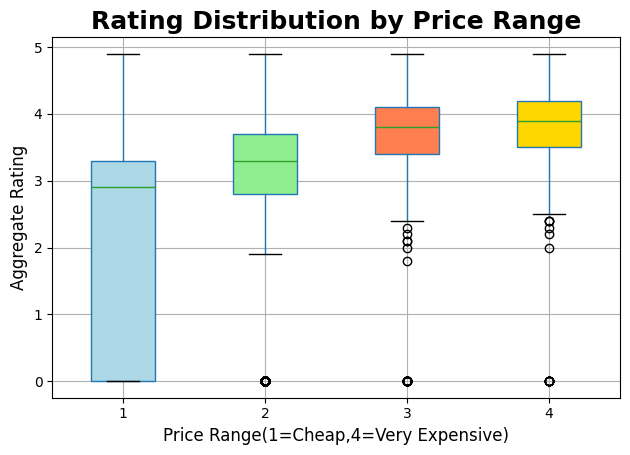

In [69]:
plt.figure(figsize=(10,6))
colors=['lightblue','lightgreen','coral','gold']
bp=df.boxplot(column='Aggregate rating',by='Price range',patch_artist=True,return_type='dict')
boxes=bp['Aggregate rating']['boxes']
for patch,color in zip(boxes,colors):
  patch.set_facecolor(color)
plt.title('Rating Distribution by Price Range',fontsize=18,fontweight='bold')
plt.suptitle('')
plt.xlabel('Price Range(1=Cheap,4=Very Expensive)',fontsize=12)
plt.ylabel('Aggregate Rating',fontsize=12)
plt.tight_layout()
plt.savefig('chart4_rating_by_price.png',dpi=150)
plt.show()

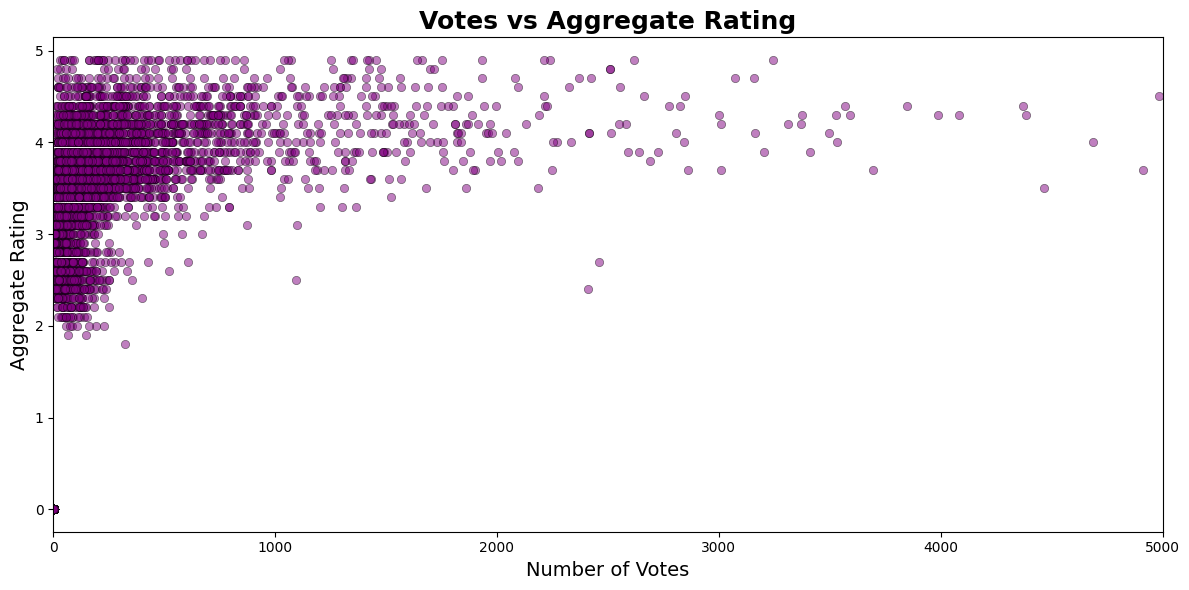

In [81]:
plt.figure(figsize=(12,6))
plt.scatter(df['Votes'],df['Aggregate rating'],alpha=0.5,color='purple',edgecolor='black',linewidths=0.5)
plt.title('Votes vs Aggregate Rating',fontsize=18,fontweight='bold')
plt.xlabel('Number of Votes',fontsize=14)
plt.ylabel('Aggregate Rating',fontsize=14)
plt.xlim(0,5000)
plt.tight_layout()
plt.savefig('chart5_votes_rating.png',dpi=150)
plt.show()

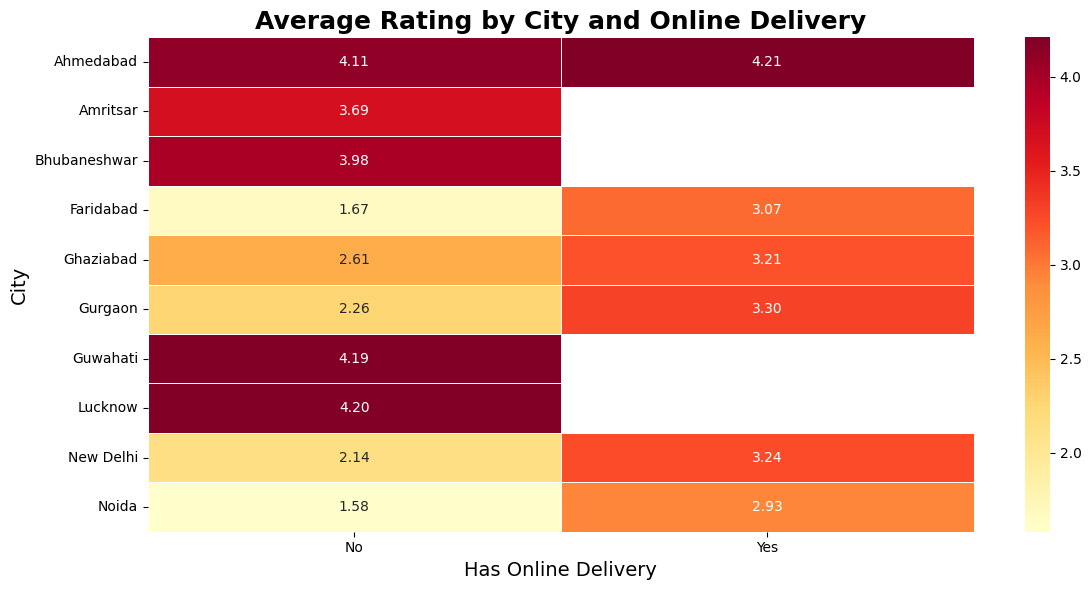

In [90]:
heatmap_data=df[df['City'].isin(city_counts.index)].groupby(
    ['City','Has Online delivery'])['Aggregate rating'].mean().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,annot=True,fmt='.2f',cmap='YlOrRd',linewidths=0.5)
plt.title('Average Rating by City and Online Delivery',fontsize=18,fontweight='bold')
plt.xlabel('Has Online Delivery',fontsize=14)
plt.ylabel('City',fontsize=14)
plt,plt.tight_layout()
plt.savefig('chart6_heatmap.png',dpi=150)
plt.show()

# Business Insights Report
## Zomato Restaurant Analysis — EDA Project
### Pluto Academy AI & ML Internship — Project 1

---

### Insight 1 — New Delhi Dominates the Restaurant Industry
**Finding:** As seen in the Top 10 Cities bar chart, New Delhi
has 5,473 restaurants — nearly 5x more than Gurgaon (1,118)
and Noida (1,080) combined.

**Recommendation:** Restaurant businesses looking to expand
should prioritize New Delhi NCR region as it has the highest
customer demand and restaurant density in India.

---

### Insight 2 — North Indian Cuisine is Most Popular
**Finding:** The Top Cuisines bar chart shows North Indian
cuisine is offered by 3,960 restaurants — 45% more than
Chinese cuisine (2,735) in second place.

**Recommendation:** New restaurants should consider offering
North Indian cuisine as their primary menu to attract maximum
customers. Adding Chinese as secondary cuisine can further
boost reach.

---

### Insight 3 — Most Restaurants Have Average Ratings
**Finding:** The rating distribution pie chart shows 39.1%
of restaurants are rated "Average" and only 3.1% are rated
"Excellent". Average rating across all restaurants is just
2.67 out of 5.

**Recommendation:** Restaurant owners should focus on improving
food quality and customer service to move from "Average" to
"Good" rating — even a small improvement can significantly
increase customer footfall.

---

### Insight 4 — Online Delivery Restaurants Have Higher Ratings
**Finding:** The delivery vs rating bar chart shows restaurants
with online delivery have significantly higher average rating
(3.25) compared to those without delivery (2.46) — a difference
of 0.79 points.

**Recommendation:** Restaurants should invest in online delivery
platforms like Zomato and Swiggy to improve customer reach and
ratings. Online delivery appears strongly correlated with better
customer satisfaction.

---

### Insight 5 — Higher Price Range = Better Ratings
**Finding:** The box plot shows clear trend — cheap restaurants
(price range 1) average 2.00 rating while very expensive
restaurants (price range 4) average 3.82 rating. Premium
restaurants consistently outperform budget ones.

**Recommendation:** Budget restaurants should focus on improving
quality of ingredients and presentation to justify higher pricing
and improve ratings. Premium pricing alone does not guarantee
success — quality must match price.

---

### 🔍 Most Surprising Finding
The most surprising finding was that restaurants with online
delivery score 0.79 points higher in ratings than those without.
This suggests that restaurants offering online delivery are
either of higher quality or that convenience of delivery
significantly improves customer satisfaction and rating behavior.
This is a strong signal for all restaurant owners to invest
in online delivery platforms.